In [1]:
import pandas as pd
import re

# Membaca file CSV
data = pd.read_csv("Data_Prepro.csv")

# Menampilkan informasi tentang dataset
data.info()

C:\Users\asus\AppData\Local\Temp\ipykernel_15932\1231610778.py:5: DtypeWarning: Columns (0,1,2,3,4,5,6,7,9,10,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("Data_Prepro.csv")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131658 entries, 0 to 131657
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   author        64923 non-null  object 
 1   content       66122 non-null  object 
 2   keyword       21288 non-null  object 
 3   link          21288 non-null  object 
 4   publish_date  21288 non-null  object 
 5   source        21288 non-null  object 
 6   title         21286 non-null  object 
 7   Period        21288 non-null  object 
 8   Bulan         21288 non-null  float64
 9   Tahun         21288 non-null  object 
 10  Clean_Text    21288 non-null  object 
 11  Tokens        21288 non-null  object 
 12  Stemmed_Text  21287 non-null  object 
dtypes: float64(1), object(12)
memory usage: 13.1+ MB


In [2]:
data.head()

,author,content,keyword,link,publish_date,source,title,Period,Bulan,Tahun,Clean_Text,Tokens,Stemmed_Text
0,NaN,"judul: author: Nonetanggal: Selasa, 01 Septe...",ekonomi yogyakarta,https://nasional.kontan.co.id/news/jokowi-bali...,2020-09-01 12:28:00,kontan.co.id,NaN,2020-09,9.0,2020.0,judul author nonetanggal selasa september wib ...,"['judul', 'author', 'nonetanggal', 'selasa', '...",judul author nonetanggal selasa september wib ...
1,NaN,judul: Ekonomi Yogyakarta Dinilai Membaik Mesk...,ekonomi yogyakarta,https://regional.kontan.co.id/news/ekonomi-yog...,2022-12-29 18:50:00,kontan.co.id,Ekonomi Yogyakarta Dinilai Membaik Meski Upah ...,2022-12,12.0,2022.0,judul ekonomi yogyakarta dinilai membaik upah ...,"['judul', 'ekonomi', 'yogyakarta', 'dinilai', ...",judul ekonomi yogyakarta nilai baik upah minim...
2,NaN,"judul: Di tengah pandemi, geliat ekonomi digit...",ekonomi yogyakarta,https://regional.kontan.co.id/news/di-tengah-p...,2021-06-01 20:38:00,kontan.co.id,"Di tengah pandemi, geliat ekonomi digital di Y...",2021-06,6.0,2021.0,judul tengah pandemi geliat ekonomi digital yo...,"['judul', 'tengah', 'pandemi', 'geliat', 'ekon...",judul tengah pandemi geliat ekonomi digital yo...
3,Oleh :\n\n\nDera Fitri,VIVA – PT Homliv Anugerah Tritunggal Indonesia...,ekonomi yogyakarta,https://www.viva.co.id/bisnis/1721077-ekspor-p...,2024-06-07 16:26:00,viva.co.id,Ekspor Produk Kayu Yogyakarta Membuka Peluang ...,2024-06,6.0,2024.0,viva perusahaan homliv anugerah tritunggal ind...,"['viva', 'perusahaan', 'homliv', 'anugerah', '...",viva usaha homliv anugerah tritunggal indonesi...
4,"Oleh :\n\n\nFikri Halim,\n ...",VIVA – Menteri Dalam Negeri (Mendagri) Tito Ka...,ekonomi yogyakarta,https://www.viva.co.id/bisnis/1419169-ekonomi-...,2021-11-01 23:18:00,viva.co.id,"Ekonomi Yogyakarta Tumbuh 11,8 Persen, Mendagr...",2021-11,11.0,2021.0,viva menteri negeri mendagri tito karnavian be...,"['viva', 'menteri', 'negeri', 'mendagri', 'tit...",viva menteri negeri mendagri tito karnavian te...


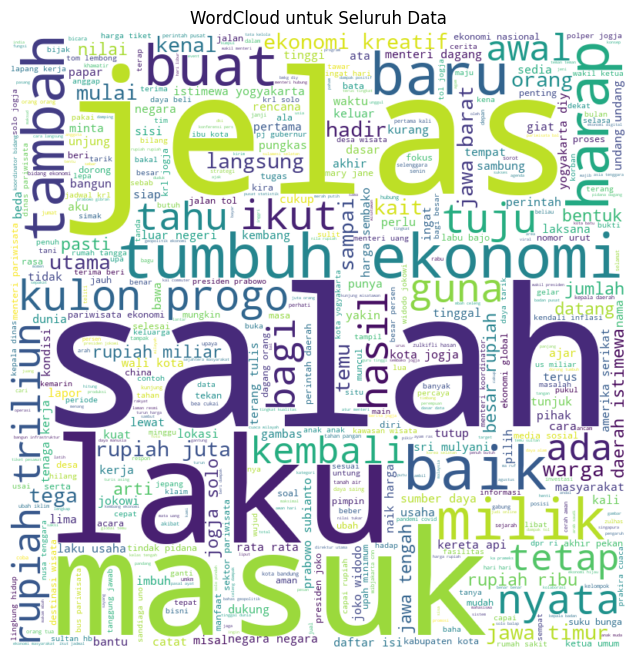

In [22]:
import pandas as pd
import numpy as np
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt

# Menggabungkan teks dari kolom 'content'
text = ' '.join(data['Stemmed_Text'].astype(str).tolist())

# Konversi teks ke huruf kecil
text = text.lower()

# Hapus tanda baca
text = re.sub(r'[^\w\s]', '', text)  # Hanya menyisakan huruf dan spasi

# Daftar stopwords tambahan
stopwords = set(STOPWORDS)
stopwords.update([
    'advertisement', 'content', 'continue', 'wib', 'scroll', 'nan', 'indonesia', 
    'tahun', 'jadi', 'ya', 'jawa barat', 'lanjut', 'lihat', 'untuk', 'dengan', 
    'jakarta', 'kata', 'ujar', 'sebut', 'ungkap', 'jela', 'dapat', 'satu', 
    'dua', 'tiga', 'jawa timur', 'ucap', 'judul', 'author','video','detik','turut'
    'jelas','baca','empat','turut','tutur'
])

# Membuat WordCloud
wc = WordCloud(stopwords=stopwords, background_color='white', 
               max_words=500, width=800, height=800)

wc.generate(text)

# Menampilkan WordCloud
plt.figure(figsize=(8, 8))
plt.imshow(wc, interpolation='bilinear')
plt.title("WordCloud untuk Seluruh Data", fontsize=12)
plt.axis("off")
plt.show()

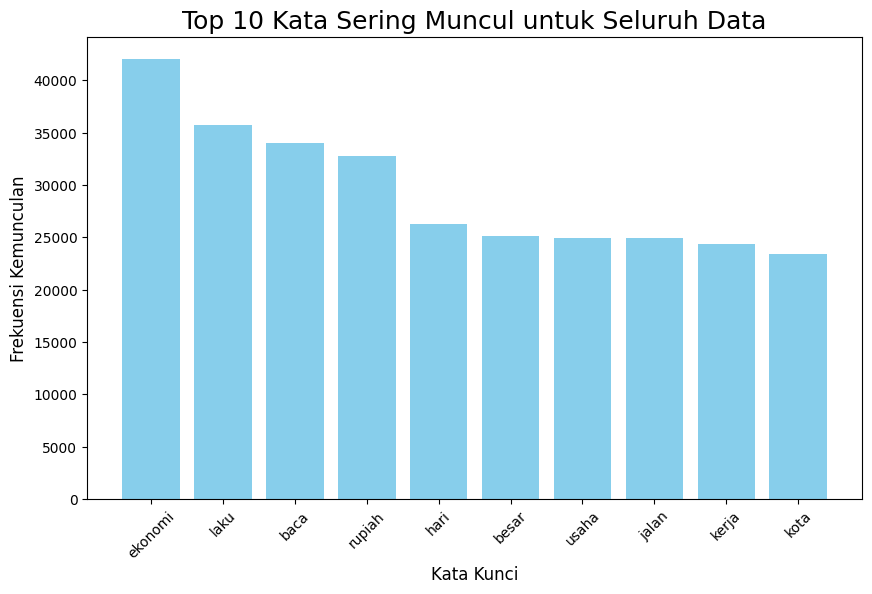

In [3]:
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import STOPWORDS

# Menggabungkan teks dari kolom 'content'
text = ' '.join(data['Stemmed_Text'].astype(str).tolist())

# Daftar stopwords tambahan
stopwords = set(STOPWORDS)
stopwords.update([
    'advertisement', 'content', 'continue', 'wib', 'scroll', 'nan', 'indonesia', 
    'tahun', 'jadi', 'ya', 'jawa barat', 'lanjut', 'lihat', 'untuk', 'dengan', 
    'jakarta', 'kata', 'ujar', 'sebut', 'ungkap', 'jela', 'dapat', 'satu', 
    'dua', 'tiga', 'jawa timur', 'ucap', 'judul', 'author', 'video', 'detik', 'turut'
])

# Tokenisasi dan hapus stopwords
tokens = [word for word in text.split() if word.lower() not in stopwords]

# Hitung frekuensi kata
word_counts = Counter(tokens)

# Ambil 10 kata paling sering muncul
top_words = word_counts.most_common(10)
words, counts = zip(*top_words)  # Pisahkan kata dan frekuensinya

# Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(words, counts, color='skyblue')
plt.xlabel("Kata Kunci", fontsize=12)
plt.ylabel("Frekuensi Kemunculan", fontsize=12)
plt.title("Top 10 Kata Sering Muncul untuk Seluruh Data", fontsize=18)
plt.xticks(rotation=45)

plt.show()


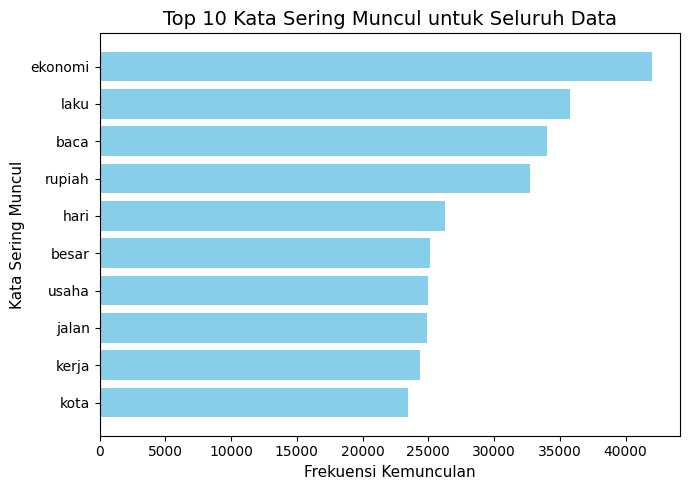

In [5]:
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import STOPWORDS

# Menggabungkan teks dari kolom 'content'
text = ' '.join(data['Stemmed_Text'].astype(str).tolist())

# Daftar stopwords tambahan
stopwords = set(STOPWORDS)
stopwords.update([
    'advertisement', 'content', 'continue', 'wib', 'scroll', 'nan', 'indonesia', 
    'tahun', 'jadi', 'ya', 'jawa barat', 'lanjut', 'lihat', 'untuk', 'dengan', 
    'jakarta', 'kata', 'ujar', 'sebut', 'ungkap', 'jela', 'dapat', 'satu', 
    'dua', 'tiga', 'jawa timur', 'ucap', 'judul', 'author', 'video', 'detik', 'turut'
])

# Tokenisasi dan hapus stopwords
tokens = [word for word in text.split() if word.lower() not in stopwords]

# Hitung frekuensi kata
word_counts = Counter(tokens)

# Ambil 10 kata paling sering muncul
top_words = word_counts.most_common(10)
words, counts = zip(*top_words)  # Pisahkan kata dan frekuensinya

# Plot horizontal bar
plt.figure(figsize=(7, 5))  # Ukuran lebih kecil dari sebelumnya
bars = plt.barh(words, counts, color='skyblue')
plt.xlabel("Frekuensi Kemunculan", fontsize=11)
plt.ylabel("Kata Sering Muncul", fontsize=11)
plt.title("Top 10 Kata Sering Muncul untuk Seluruh Data", fontsize=14)
plt.gca().invert_yaxis()  # Supaya kata dengan frekuensi terbesar di atas

plt.tight_layout()
plt.show()


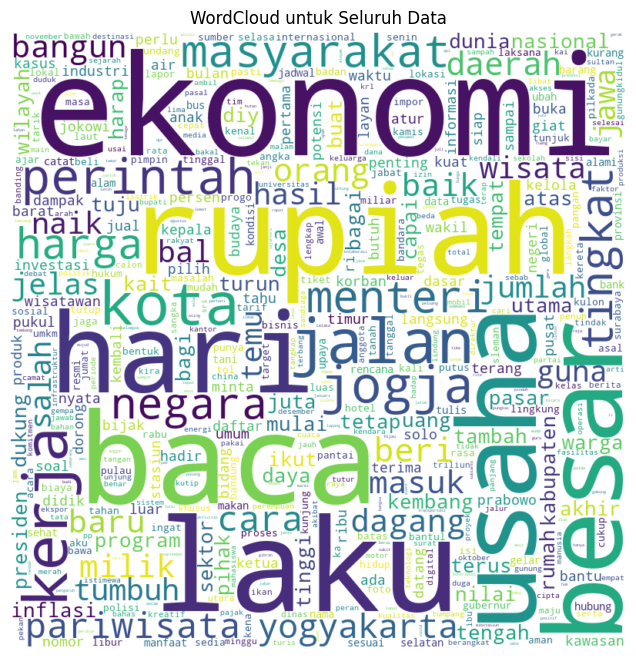

In [28]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
from collections import Counter

# Menggabungkan teks dari kolom 'content'
text = ' '.join(data['Stemmed_Text'].astype(str).tolist())

# Daftar stopwords tambahan
stopwords = set(STOPWORDS)
stopwords.update([
    'advertisement', 'content', 'continue', 'wib', 'scroll', 'nan', 'indonesia', 
    'tahun', 'jadi', 'ya', 'jawa barat', 'lanjut', 'lihat', 'untuk', 'dengan', 
    'jakarta', 'kata', 'ujar', 'sebut', 'ungkap', 'jela', 'dapat', 'satu', 
    'dua', 'tiga', 'jawa timur', 'ucap', 'judul', 'author', 'video', 'detik', 'turut'
])

# Tokenisasi dan hapus stopwords
tokens = [word for word in text.split() if word.lower() not in stopwords]

# Hitung frekuensi kata
word_counts = Counter(tokens)

# Buat objek WordCloud
wc = WordCloud(
    background_color='white',
    width=800, 
    height=800, 
    max_words=500, 
    stopwords=stopwords,
    colormap='viridis' # Bisa diganti dengan colormap lain seperti 'plasma', 'coolwarm', dll.
).generate_from_frequencies(word_counts)

# Tampilkan WordCloud
plt.figure(figsize=(8, 8))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.title("WordCloud untuk Seluruh Data", fontsize=12)
plt.show()


In [5]:
import pandas as pd

# Membaca file CSV
data = pd.read_csv("Hasil_Preprocessing_Data.csv")

# Menampilkan informasi tentang dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131658 entries, 0 to 131657
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   author        64923 non-null  object 
 1   content       66122 non-null  object 
 2   keyword       21288 non-null  object 
 3   link          21288 non-null  object 
 4   publish_date  21288 non-null  object 
 5   source        21288 non-null  object 
 6   title         21286 non-null  object 
 7   Period        21288 non-null  object 
 8   Bulan         21288 non-null  float64
 9   Tahun         21288 non-null  object 
 10  Clean_Text    21288 non-null  object 
 11  Tokens        21288 non-null  object 
 12  Stemmed_Text  21287 non-null  object 
dtypes: float64(1), object(12)
memory usage: 13.1+ MB


C:\Users\asus\AppData\Local\Temp\ipykernel_18168\1877333408.py:4: DtypeWarning: Columns (0,1,2,3,4,5,6,7,9,10,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("Hasil_Preprocessing_Data.csv")


In [6]:
df = data.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20088 entries, 3 to 131657
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   author        20088 non-null  object 
 1   content       20088 non-null  object 
 2   keyword       20088 non-null  object 
 3   link          20088 non-null  object 
 4   publish_date  20088 non-null  object 
 5   source        20088 non-null  object 
 6   title         20088 non-null  object 
 7   Period        20088 non-null  object 
 8   Bulan         20088 non-null  float64
 9   Tahun         20088 non-null  object 
 10  Clean_Text    20088 non-null  object 
 11  Tokens        20088 non-null  object 
 12  Stemmed_Text  20088 non-null  object 
dtypes: float64(1), object(12)
memory usage: 2.1+ MB


In [7]:
data = pd.DataFrame(df[['publish_date', 'author', 'Stemmed_Text']])
data.head(5)

,publish_date,author,Stemmed_Text
3,2024-06-07 16:26:00,Oleh :\n\n\nDera Fitri,viva usaha homliv anugerah tritunggal indonesi...
4,2021-11-01 23:18:00,"Oleh :\n\n\nFikri Halim,\n ...",viva menteri negeri mendagri tito karnavian te...
5,2021-11-15 09:25:00,Oleh :\n\n\nSyahdan Nurdin,viva rektor universitas widya mataram uwm yogy...
6,2023-03-08 16:11:00,Oleh :\n\n\nDera Fitri,viva senantiasa dorong industri tumbuh ekonomi...
7,2022-05-02 15:51:00,"Oleh :\n\n\nMohammad Arief Hidayat,\n ...",viva presiden joko widodo terima kunjung mente...


In [11]:
import pandas as pd

# Baca kamus leksikon positif dan negatif
positive_lexicon = set(pd.read_csv("positive.tsv", sep="\t", header=None)[0])
negative_lexicon = set(pd.read_csv("negative.tsv", sep="\t", header=None)[0])

# Fungsi untuk menentukan sentimen dan menghitung compound score
def determine_sentiment_and_score(text):
    if isinstance(text, str):
        words = text.split()
        total_words = len(words)
        positive_count = sum(1 for word in words if word in positive_lexicon)
        negative_count = sum(1 for word in words if word in negative_lexicon)

        # Tentukan sentimen (tanpa Neutral)
        if positive_count >= negative_count:
            sentiment = "Positive"
        else:
            sentiment = "Negative"

        # Hitung compound score
        compound_score = (positive_count - negative_count) / total_words if total_words > 0 else 0

        return pd.Series([sentiment, compound_score])
    else:
        return pd.Series(["Positive", 0])  # Default ke "Positive" jika teks tidak valid

# Terapkan fungsi pada kolom Stemming
data[['Sentiment', 'Compound_Score']] = data['Stemmed_Text'].apply(determine_sentiment_and_score)

# Tampilkan hasil
print(data[['Stemmed_Text', 'Sentiment', 'Compound_Score']].head(30))

data.head(10)


                                         Stemmed_Text Sentiment  \
3   viva usaha homliv anugerah tritunggal indonesi...  Positive   
4   viva menteri negeri mendagri tito karnavian te...  Positive   
5   viva rektor universitas widya mataram uwm yogy...  Positive   
6   viva senantiasa dorong industri tumbuh ekonomi...  Positive   
7   viva presiden joko widodo terima kunjung mente...  Positive   
8   viva dukung industri negeri saing pasar intern...  Positive   
9   warga yogyakarta hari rasa air sumur sulit bik...  Negative   
10  kembang pariwisata daerah istimewa yogyakarta ...  Positive   
11  target kejar indonesia wujud raya merdeka repu...  Positive   
12  akibat tutup tpa piyungan maret sampah depo ko...  Negative   
13  ada kedai kopi yogyakarta jamur musim hujan su...  Negative   
14  terumbu karang coral reefs salah satu bagi eko...  Negative   
15  populasi manusia dunia kira capai miliar jiwa ...  Negative   
16  kaya laut indonesia besar aku dunia salah satu...  Positiv

,publish_date,author,Stemmed_Text,Sentiment,Compound_Score
3,2024-06-07 16:26:00,Oleh :\n\n\nDera Fitri,viva usaha homliv anugerah tritunggal indonesi...,Positive,0.021429
4,2021-11-01 23:18:00,"Oleh :\n\n\nFikri Halim,\n ...",viva menteri negeri mendagri tito karnavian te...,Positive,0.039604
5,2021-11-15 09:25:00,Oleh :\n\n\nSyahdan Nurdin,viva rektor universitas widya mataram uwm yogy...,Positive,0.070423
6,2023-03-08 16:11:00,Oleh :\n\n\nDera Fitri,viva senantiasa dorong industri tumbuh ekonomi...,Positive,0.081433
7,2022-05-02 15:51:00,"Oleh :\n\n\nMohammad Arief Hidayat,\n ...",viva presiden joko widodo terima kunjung mente...,Positive,0.093750
8,2023-03-15 18:16:00,Oleh :\n\n\nDera Fitri,viva dukung industri negeri saing pasar intern...,Positive,0.079812
9,2022-03-27 00:00:00,Lusia Arumingtyas dan Maria Junia [Yogyakarta]*,warga yogyakarta hari rasa air sumur sulit bik...,Negative,-0.036306
10,2021-06-24 00:00:00,Anggalih Bayu Muh. Kamim *,kembang pariwisata daerah istimewa yogyakarta ...,Positive,0.002132
11,2023-09-29 00:00:00,M Ambari [Jakarta],target kejar indonesia wujud raya merdeka repu...,Positive,0.042728
12,2024-11-26 00:00:00,Sidney Alvionita Saputra*,akibat tutup tpa piyungan maret sampah depo ko...,Negative,-0.071987


In [12]:
# Menampilkan jumlah masing-masing label di Label_InSet
label_counts = data['Sentiment'].value_counts()
print(label_counts)

Sentiment
Positive    12589
Negative     7499
Name: count, dtype: int64


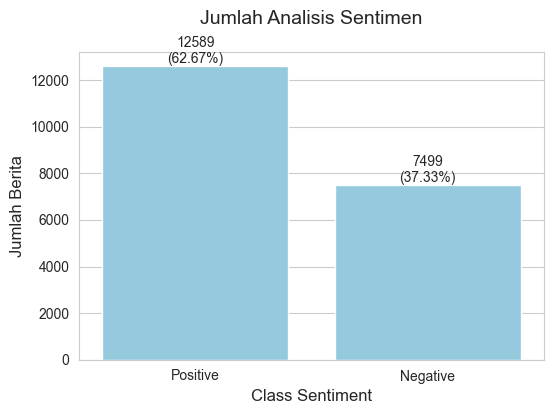

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sentiment_count = data['Sentiment'].value_counts()
sns.set_style('whitegrid')

fig, ax = plt.subplots(figsize=(6,4))
ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, color='skyblue')
plt.title('Jumlah Analisis Sentimen', fontsize=14, pad=20)
plt.xlabel('Class Sentiment', fontsize=12)
plt.ylabel('Jumlah Berita',fontsize=12)

total = len(data['Sentiment'])

for i, count in enumerate(sentiment_count.values):
    percentage = f'{100 * count / total:.2f}%'
    ax.text(i, count + 0.10, f'{count}\n({percentage})', ha='center', va='bottom')

plt.show()

In [14]:
data.to_csv('Hasil_Labelling_2_Lexicon_Data.csv', encoding='utf8', index=False)

In [4]:
import pandas as pd

data = pd.read_csv("Hasil_Labelling_2_Lexicon_Data.csv")
data.head(200)

,publish_date,author,Stemmed_Text,Sentiment,Compound_Score
0,2024-06-07 16:26:00,Oleh :\n\n\nDera Fitri,viva usaha homliv anugerah tritunggal indonesi...,Positive,0.021429
1,2021-11-01 23:18:00,"Oleh :\n\n\nFikri Halim,\n ...",viva menteri negeri mendagri tito karnavian te...,Positive,0.039604
2,2021-11-15 09:25:00,Oleh :\n\n\nSyahdan Nurdin,viva rektor universitas widya mataram uwm yogy...,Positive,0.070423
3,2023-03-08 16:11:00,Oleh :\n\n\nDera Fitri,viva senantiasa dorong industri tumbuh ekonomi...,Positive,0.081433
4,2022-05-02 15:51:00,"Oleh :\n\n\nMohammad Arief Hidayat,\n ...",viva presiden joko widodo terima kunjung mente...,Positive,0.093750
...,...,...,...,...,...
195,2024-12-05 14:31:00,Andi Hidayat - detikFinance,jakarta menteri badan usaha milik negara bumn ...,Positive,0.037736
196,2024-09-05 19:40:00,Panji Saputro - detikInet,jakarta studio game indonesia sukses ikut pame...,Positive,0.125899
197,2024-08-22 19:51:00,Adji G Rinepta - detikJogja,jogja pemda daerah istimewa yogyakarta diy ten...,Positive,0.035714
198,2024-09-29 14:20:00,Tya Eka Yulianti - detikJabar,kabupaten bandung otoritas jasa uang ojk anggo...,Positive,0.000000


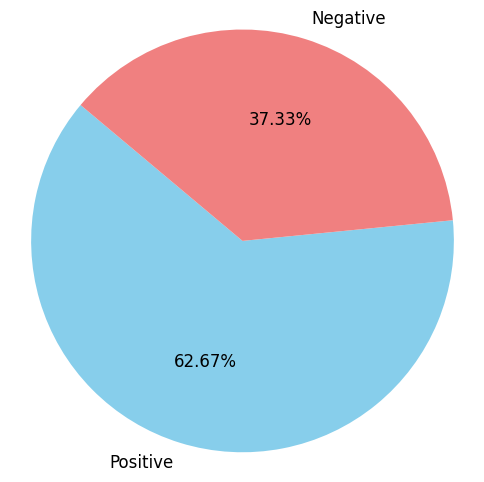

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Menghitung jumlah sentimen positif dan negatif
sentiment_count = data['Sentiment'].value_counts()

# Membuat diagram lingkaran (pie chart)
plt.figure(figsize=(6, 6))
colors = ['skyblue', 'lightcoral']  # Warna untuk sentimen positif dan negatif
plt.pie(sentiment_count.values, labels=sentiment_count.index, autopct='%1.2f%%', 
        startangle=140, colors=colors, textprops={'fontsize': 12})


plt.axis('equal')  # Agar pie chart berbentuk lingkaran sempurna
plt.show()

In [30]:
import pandas as pd
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Pisahkan dataset berdasarkan sentimen
sentimen_Negative = data[data['Sentiment'] == 'Negative']['Stemmed_Text'].str.cat(sep=' ')
sentimen_Positive = data[data['Sentiment'] == 'Positive']['Stemmed_Text'].str.cat(sep=' ')

In [31]:
stopwords = set(STOPWORDS)
stopwords.update(['advertisement','content','continue','wib','scroll','nan','indonesia','tahun','jadi','untuk','dengan','jakarta'])

# Fungsi untuk membuat dan menampilkan WordCloud
def create_wordcloud(text, title):
    wordcloud = WordCloud(stopwords=stopwords, width=800, height=800, random_state=42, max_font_size=100, background_color='white').generate(text)

    plt.figure(figsize=(3, 3))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

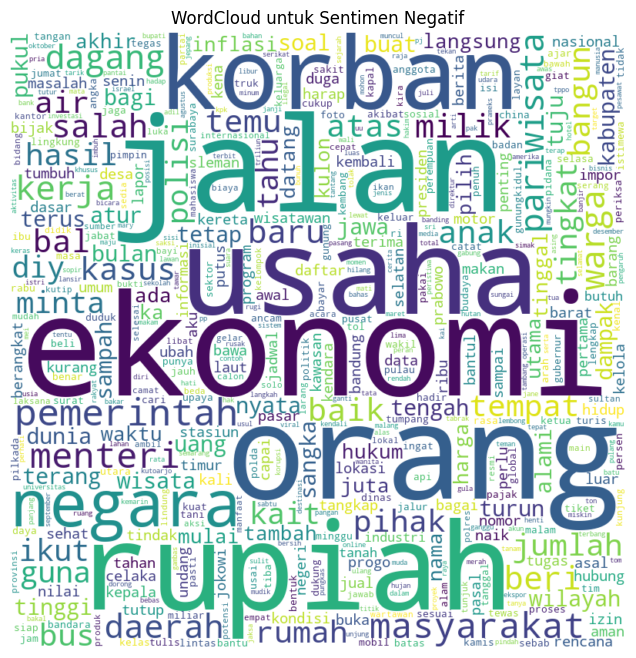

In [60]:
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud, STOPWORDS

# Filter data untuk hanya mengambil baris dengan sentimen negatif
data_negatif = data[data['Sentiment'] == 'Negative']

# Gabungkan teks dari kolom 'Stemmed_Text' pada data negatif
text_negatif = ' '.join(data_negatif['Stemmed_Text'].astype(str).tolist())

# Ganti kata "perintah" menjadi "pemerintah"
text_negatif = text_negatif.replace("perintah", "pemerintah")

# Daftar stopwords tambahan
stopwords = set(STOPWORDS)
stopwords.update([
    'advertisement', 'content', 'continue', 'wib', 'scroll', 'nan', 'indonesia', 
    'tahun', 'jadi', 'ya', 'jawa barat', 'lanjut', 'lihat', 'untuk', 'dengan', 
    'jakarta', 'kata', 'ujar', 'sebut', 'ungkap', 'jela', 'dapat', 'satu', 
    'dua', 'tiga', 'jawa timur', 'ucap', 'judul', 'author', 'video', 'detik', 'turut','baca','kota','jogja'
    'orang','besar','hari','laku','masuk','cara','jogja','yogyakarta','jelas'
])

# Tokenisasi dan hapus stopwords
tokens_negatif = [word for word in text_negatif.split() if word.lower() not in stopwords]

# Hitung frekuensi kata
word_counts_negatif = Counter(tokens_negatif)

# Buat objek WordCloud
wc_negatif = WordCloud(
    background_color='white',
    width=800, 
    height=800, 
    max_words=500, 
    stopwords=stopwords,
    colormap='viridis'  # Menggunakan warna merah untuk menandakan sentimen negatif
).generate_from_frequencies(word_counts_negatif)

# Tampilkan WordCloud
plt.figure(figsize=(8, 8))
plt.imshow(wc_negatif, interpolation='bilinear')
plt.axis("off")
plt.title("WordCloud untuk Sentimen Negatif", fontsize=12)
plt.show()


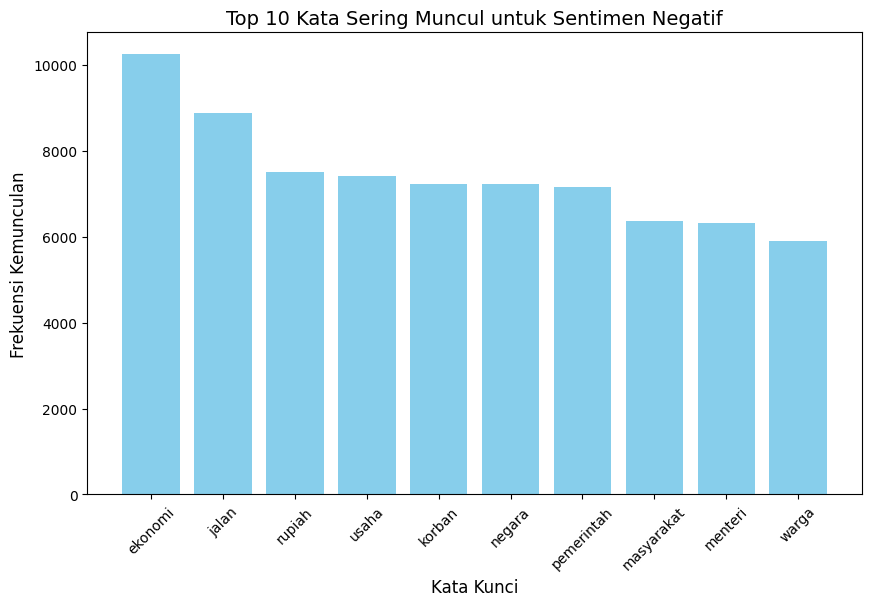

In [59]:
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import STOPWORDS

# Filter data untuk hanya mengambil baris dengan sentimen negatif
data_negatif = data[data['Sentiment'] == 'Negative']

# Gabungkan teks dari kolom 'Stemmed_Text' pada data negatif
text_negatif = ' '.join(data_negatif['Stemmed_Text'].astype(str).tolist())

# Ganti kata "perintah" menjadi "pemerintah"
text_negatif = text_negatif.replace("perintah", "pemerintah")

# Daftar stopwords tambahan
stopwords = set(STOPWORDS)
stopwords.update([
    'advertisement', 'content', 'continue', 'wib', 'scroll', 'nan', 'indonesia', 
    'tahun', 'jadi', 'ya', 'jawa barat', 'lanjut', 'lihat', 'untuk', 'dengan', 
    'jakarta', 'kata', 'ujar', 'sebut', 'ungkap', 'jela', 'dapat', 'satu', 
    'dua', 'tiga', 'jawa timur', 'ucap', 'judul', 'author', 'video', 'detik', 
    'turut', 'baca', 'kota', 'jogja', 'orang', 'besar', 'hari','laku','masuk','cara','yogyakarta','jelas'
])

# Tokenisasi dan hapus stopwords
tokens_negatif = [word for word in text_negatif.split() if word.lower() not in stopwords]

# Hitung frekuensi kata
word_counts_negatif = Counter(tokens_negatif)

# Ambil 10 kata paling sering muncul
top_words = word_counts_negatif.most_common(10)

# Pisahkan kata dan frekuensinya
words, counts = zip(*top_words)

# Buat bar plot vertikal
plt.figure(figsize=(10, 6))
plt.bar(words, counts, color='skyblue')  # Bar plot vertikal
plt.ylabel("Frekuensi Kemunculan", fontsize=12)
plt.xlabel("Kata Kunci", fontsize=12)
plt.title("Top 10 Kata Sering Muncul untuk Sentimen Negatif", fontsize=14)
plt.xticks(rotation=45)  # Rotasi label agar lebih mudah dibaca


# Tampilkan plot
plt.show()



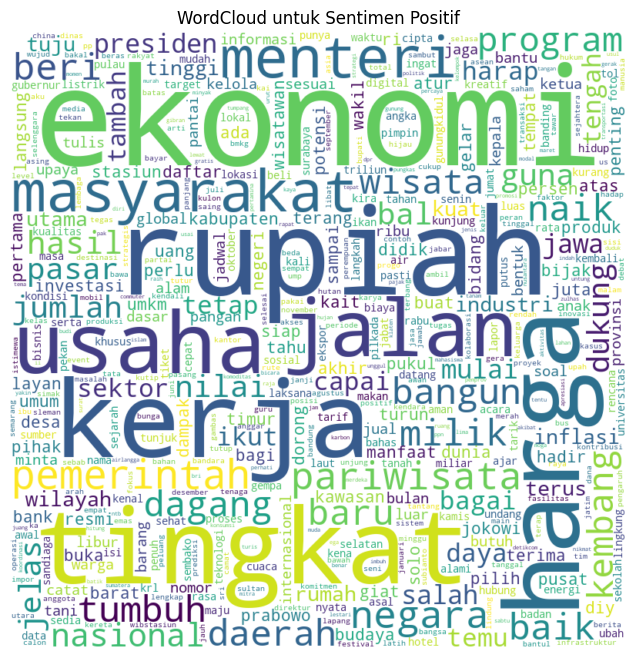

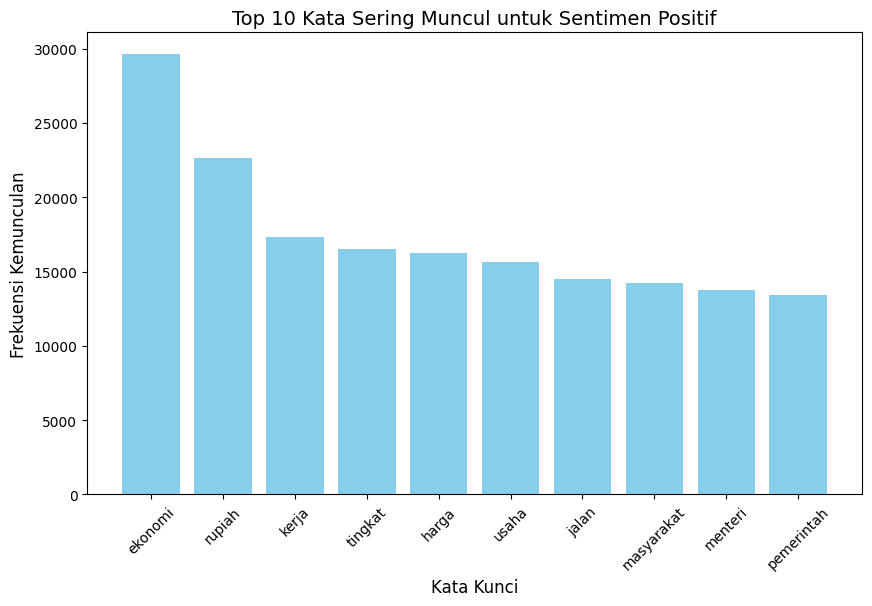

In [58]:
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud, STOPWORDS

# Filter data untuk hanya mengambil baris dengan sentimen positif
data_positif = data[data['Sentiment'] == 'Positive']

# Gabungkan teks dari kolom 'Stemmed_Text' pada data positif
text_positif = ' '.join(data_positif['Stemmed_Text'].astype(str).tolist())

# Ganti kata "perintah" menjadi "pemerintah"
text_positif = text_positif.replace("perintah", "pemerintah")

# Daftar stopwords tambahan
stopwords = set(STOPWORDS)
stopwords.update([
    'advertisement', 'content', 'continue', 'wib', 'scroll', 'nan', 'indonesia', 
    'tahun', 'jadi', 'ya', 'jawa barat', 'lanjut', 'lihat', 'untuk', 'dengan', 
    'jakarta', 'kata', 'ujar', 'sebut', 'ungkap', 'jela', 'dapat', 'satu', 
    'dua', 'tiga', 'jawa timur', 'ucap', 'judul', 'author', 'video', 'detik', 
    'turut', 'baca', 'kota', 'jogja', 'orang', 'besar', 'hari', 'laku', 
    'masuk', 'cara', 'yogyakarta'
])

# Tokenisasi dan hapus stopwords
tokens_positif = [word for word in text_positif.split() if word.lower() not in stopwords]

# Hitung frekuensi kata
word_counts_positif = Counter(tokens_positif)

# Buat WordCloud
wc_positif = WordCloud(
    background_color='white',
    width=800, 
    height=800, 
    max_words=500, 
    stopwords=stopwords,
    colormap='viridis'  # Menggunakan skema warna biru untuk sentimen positif
).generate_from_frequencies(word_counts_positif)

# Tampilkan WordCloud
plt.figure(figsize=(8, 8))
plt.imshow(wc_positif, interpolation='bilinear')
plt.axis("off")
plt.title("WordCloud untuk Sentimen Positif", fontsize=12)
plt.show()

# Ambil 10 kata paling sering muncul
top_words = word_counts_positif.most_common(10)

# Pisahkan kata dan frekuensinya
words, counts = zip(*top_words)

# Buat bar plot
plt.figure(figsize=(10, 6))
plt.bar(words, counts, color='skyblue')
plt.ylabel("Frekuensi Kemunculan", fontsize=12)
plt.xlabel("Kata Kunci", fontsize=12)
plt.title("Top 10 Kata Sering Muncul untuk Sentimen Positif", fontsize=14)
plt.xticks(rotation=45)


plt.show()


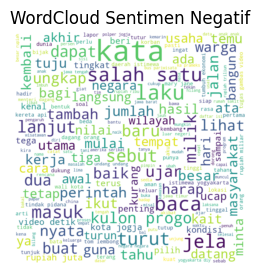

In [33]:
# Membuat WordCloud untuk sentimen negatif
create_wordcloud(sentimen_Negative, 'WordCloud Sentimen Negatif')

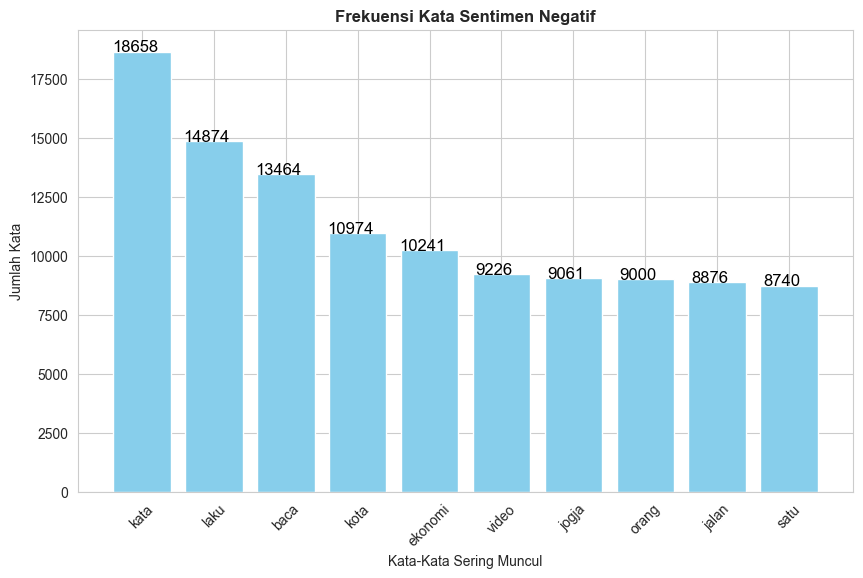

In [20]:
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import STOPWORDS

# sentimen_Negative
text = sentimen_Negative

stopwords = set(STOPWORDS)
stopwords.update(['advertisement','content','continue','wib','scroll','nan','indonesia','tahun','jadi','untuk','dengan','jakarta'])

tokens = [word for word in text.split() if word not in stopwords]
word_counts = Counter(tokens)

top_words = word_counts.most_common(10 )
word, count = zip(*top_words)

#Definisikan palet warna
colors = ['skyblue' for _ in range(len(word))]

plt.figure(figsize=(10, 6))
bars = plt.bar(word, count, color=colors)
plt.xlabel("Kata-Kata Sering Muncul", fontsize=10)
plt.ylabel("Jumlah Kata", fontsize=10)
plt.title("Frekuensi Kata Sentimen Negatif", fontsize=12, fontweight='bold')
plt.xticks(rotation=45)

#Menambahkan angka rata tengah di atas setiap bar
for bar, num in zip(bars, count):
    plt.text(bar.get_x() + bar.get_width() / 2 - 0.1, num + 1, str(num), fontsize=12, color='black', ha='center')

plt.show()

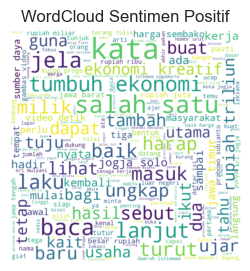

In [21]:
# Membuat WordCloud untuk sentimen positive
create_wordcloud(sentimen_Positive, 'WordCloud Sentimen Positif')

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from wordcloud import WordCloud, STOPWORDS
from collections import Counter

# --- 1. Load Data (sesuai yang Anda pakai sebelumnya) ---
train_data = pd.read_csv("train.csv")
test_data = pd.read_csv("test.csv")

# Pastikan ada kolom 'Stemmed_Text' di kedua dataset
# Jika label sentimen asli juga ada, itu bagus untuk perbandingan

# --- 2. TF-IDF Vectorization ---
# Inisialisasi dan fit TfidfVectorizer pada data latih asli (sebelum SMOTE)
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(train_data['Stemmed_Text'])
X_test_tfidf = tfidf.transform(test_data['Stemmed_Text'])

# Target labels (asli dari data)
y_train_actual = train_data['Sentiment']
y_test_actual = test_data['Sentiment']

# --- 3. Apply SMOTE (pada data training saja) ---
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_tfidf, y_train_actual)

# --- 4. Hyperparameter Tuning using GridSearchCV for RBF kernel ---
param_grid = {
    'C': [1, 10, 100],  # Regularization parameter
    'gamma': ['scale', 0.1]  # Gamma parameter for RBF kernel
}
grid_search = GridSearchCV(SVC(kernel='rbf'), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_resampled, y_train_resampled)

# --- 5. Use the best model from GridSearch ---
best_svm_model = grid_search.best_estimator_

# --- 6. PREDIKSI SENTIMEN DARI MODEL SVM TERBAIK ---
# Prediksi pada data latih (opsional, untuk melihat kinerja training)
y_pred_train_svm = best_svm_model.predict(X_train_tfidf)

# Prediksi pada DATA UJI (Ini yang paling penting untuk evaluasi dan visualisasi hasil model)
y_pred_test_svm = best_svm_model.predict(X_test_tfidf)

# --- 7. MENYIMPAN HASIL PREDIKSI KE DATAFRAME ASLI ---

# Menambahkan kolom prediksi ke test_data
test_data_with_predictions = test_data.copy() # Buat salinan agar data asli tidak berubah
test_data_with_predictions['Predicted_Sentiment_SVM'] = y_pred_test_svm

# Jika Anda juga ingin menyimpan prediksi untuk data latih (opsional):
train_data_with_predictions = train_data.copy()
train_data_with_predictions['Predicted_Sentiment_SVM'] = y_pred_train_svm

# --- 8. MENGGABUNGKAN PREDIKSI KE SATU DATAFRAME UNTUK VISUALISASI ---
# Gabungkan kembali stemmed_text dari data train dan test, bersama dengan prediksi SVM
# Ini penting jika Anda ingin membuat wordcloud/barplot dari seluruh data yang diprediksi oleh SVM

# Buat DataFrame baru hanya dengan teks dan sentimen prediksi SVM
# Menggunakan test_data_with_predictions karena ini adalah data yang belum pernah dilihat model
# Jika ingin seluruh data prediksi (train+test) maka gabungkan keduanya
all_predicted_data = pd.concat([train_data_with_predictions, test_data_with_predictions], ignore_index=True)


# --- Anda sekarang bisa menggunakan 'all_predicted_data' untuk visualisasi ---
# Misalnya, untuk memvisualisasikan wordcloud/barplot berdasarkan sentimen prediksi SVM:

# Filter data berdasarkan sentimen Positif dan Negatif dari HASIL PREDIKSI SVM
positive_predicted_sentiment_data = all_predicted_data[all_predicted_data['Predicted_Sentiment_SVM'] == 'Positive']
negative_predicted_sentiment_data = all_predicted_data[all_predicted_data['Predicted_Sentiment_SVM'] == 'Negative']

# --- Contoh Visualisasi WordCloud Positif (menggunakan prediksi SVM) ---
if not positive_predicted_sentiment_data.empty:
    predicted_positive_text = ' '.join(positive_predicted_sentiment_data['Stemmed_Text'].astype(str).tolist())
    predicted_positive_tokens = [word for word in predicted_positive_text.split() if word.lower() not in stopwords_indo] # stopwords_indo dari code Anda sebelumnya
    predicted_positive_word_counts = Counter(predicted_positive_tokens)

    wc_predicted_positive = WordCloud(
        background_color='white',
        width=800,
        height=800,
        max_words=500,
        stopwords=stopwords_indo,
        colormap='Greens'
    ).generate_from_frequencies(predicted_positive_word_counts)

    plt.figure(figsize=(8, 8))
    plt.imshow(wc_predicted_positive, interpolation='bilinear')
    plt.axis("off")
    plt.title("WordCloud Sentimen Positif (Prediksi SVM)", fontsize=12)
    plt.show()

NameError: name 'stopwords_indo' is not defined

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from wordcloud import WordCloud, STOPWORDS # Pastikan WordCloud diimpor
from collections import Counter

# --- 1. Load Data (sesuai yang Anda pakai sebelumnya) ---
train_data = pd.read_csv("train.csv")
test_data = pd.read_csv("test.csv")

# Gabungkan data train dan test jika Stemmed_Text dan Sentiment ada di keduanya
# Jika Stemmed_Text dan Sentiment ada di satu file CSV saja, sesuaikan loadernya
data = pd.concat([train_data, test_data], ignore_index=True)


# --- DEFENISI STOPWORDS SEBELUM DIGUNAKAN ---
# Daftar stopwords tambahan Anda (pastikan ini ada di bagian atas dan terdefinisi)
stopwords_indo = set(STOPWORDS)
stopwords_indo.update([
    'advertisement', 'content', 'continue', 'wib', 'scroll', 'nan', 'indonesia',
    'tahun', 'jadi', 'ya', 'jawa barat', 'lanjut', 'lihat', 'untuk', 'dengan',
    'jakarta', 'kata', 'ujar', 'sebut', 'ungkap', 'jela', 'dapat', 'satu',
    'dua', 'tiga', 'jawa timur', 'ucap', 'judul', 'author', 'video', 'detik', 'turut',
    # Tambahkan stopword dari stemming/normalization jika masih ada
    'semakin', 'membuat', 'rasa', 'sulit', 'terjadi', 'penyebabnya', 'seringkali', 'sertai',
    'kendali', 'awas', 'bangun', 'jamur', 'tiap', 'setiap', 'sudut', 'kota', 'hari', 'air',
    'sumur', 'dalam', 'kemarau', 'kering', 'sebab', 'sektor', 'primadona', 'disertai',
    'pengendalian', 'pengawasan', 'optimal', 'pembangunan', 'hotel', 'menjamur'
])


# --- 2. TF-IDF Vectorization ---
# Inisialisasi dan fit TfidfVectorizer pada data latih asli (sebelum SMOTE)
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(train_data['Stemmed_Text'])
X_test_tfidf = tfidf.transform(test_data['Stemmed_Text'])

# Target labels (asli dari data)
y_train_actual = train_data['Sentiment']
y_test_actual = test_data['Sentiment']

# --- 3. Apply SMOTE (pada data training saja) ---
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_tfidf, y_train_actual)

# --- 4. Hyperparameter Tuning using GridSearchCV for RBF kernel ---
param_grid = {
    'C': [1, 10, 100],  # Regularization parameter
    'gamma': ['scale', 0.1]  # Gamma parameter for RBF kernel
}
grid_search = GridSearchCV(SVC(kernel='rbf'), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_resampled, y_train_resampled)

# --- 5. Use the best model from GridSearch ---
best_svm_model = grid_search.best_estimator_

# --- 6. PREDIKSI SENTIMEN DARI MODEL SVM TERBAIK ---
y_pred_train_svm = best_svm_model.predict(X_train_tfidf)
y_pred_test_svm = best_svm_model.predict(X_test_tfidf)

# --- 7. MENYIMPAN HASIL PREDIKSI KE DATAFRAME ASLI ---
train_data_with_predictions = train_data.copy()
train_data_with_predictions['Predicted_Sentiment_SVM'] = y_pred_train_svm

test_data_with_predictions = test_data.copy()
test_data_with_predictions['Predicted_Sentiment_SVM'] = y_pred_test_svm

all_predicted_data = pd.concat([train_data_with_predictions, test_data_with_predictions], ignore_index=True)

--- Visualisasi Sentimen Positif (Berdasarkan Prediksi SVM) ---


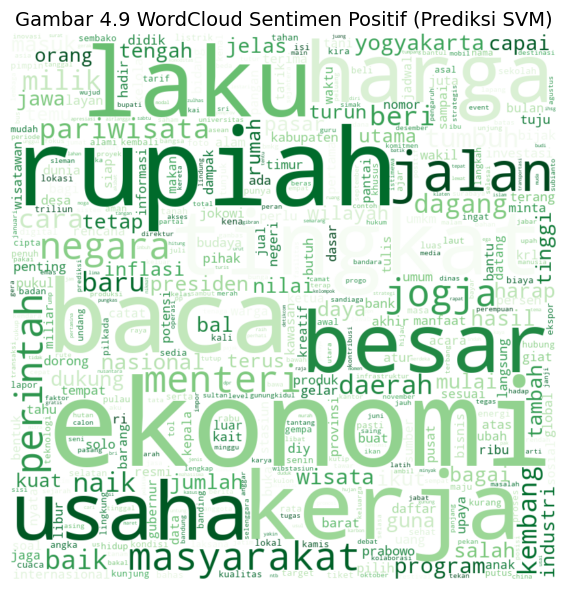

In [8]:
# --- VISUALISASI WORDCLOUD DAN BARPLOT SENTIMEN POSITIF ---
print("--- Visualisasi Sentimen Positif (Berdasarkan Prediksi SVM) ---")

# Filter data berdasarkan sentimen Positif dari HASIL PREDIKSI SVM
positive_predicted_sentiment_data = all_predicted_data[all_predicted_data['Predicted_Sentiment_SVM'] == 'Positive']

# WordCloud Positif
if not positive_predicted_sentiment_data.empty:
    predicted_positive_text = ' '.join(positive_predicted_sentiment_data['Stemmed_Text'].astype(str).tolist())
    predicted_positive_tokens = [word for word in predicted_positive_text.split() if word.lower() not in stopwords_indo]
    predicted_positive_word_counts = Counter(predicted_positive_tokens)

    wc_predicted_positive = WordCloud(
        background_color='white',
        width=800,
        height=800,
        max_words=500,
        stopwords=stopwords_indo,
        colormap='Greens' # Colormap yang cocok untuk positif
    ).generate_from_frequencies(predicted_positive_word_counts)

    plt.figure(figsize=(10, 6)) # Ukuran figura disesuaikan untuk skripsi
    plt.imshow(wc_predicted_positive, interpolation='bilinear')
    plt.axis("off")
    plt.title("Gambar 4.9 WordCloud Sentimen Positif (Prediksi SVM)", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada data dengan sentimen Positif (prediksi SVM) untuk WordCloud.")

--- Visualisasi Sentimen Positif (Berdasarkan Prediksi SVM) ---


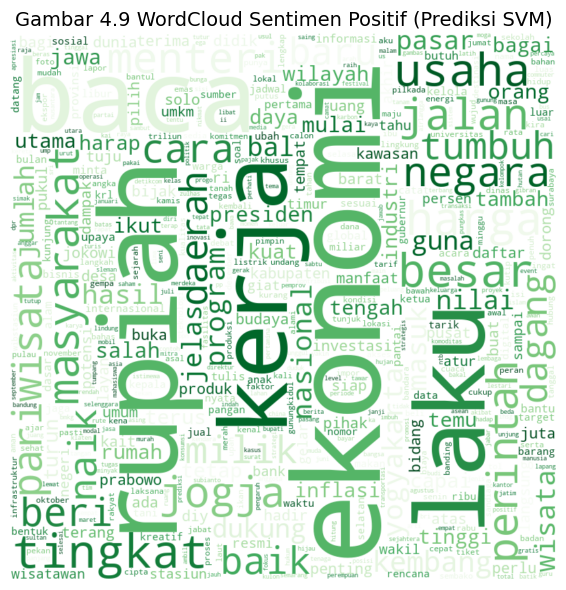

C:\Users\asus\AppData\Local\Temp\ipykernel_15932\1833769326.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts_pos), y=list(words_pos), palette='Greens_r', orient='h') # Pilihan 1: Menggunakan palette 'Greens_r' (reversed Greens)


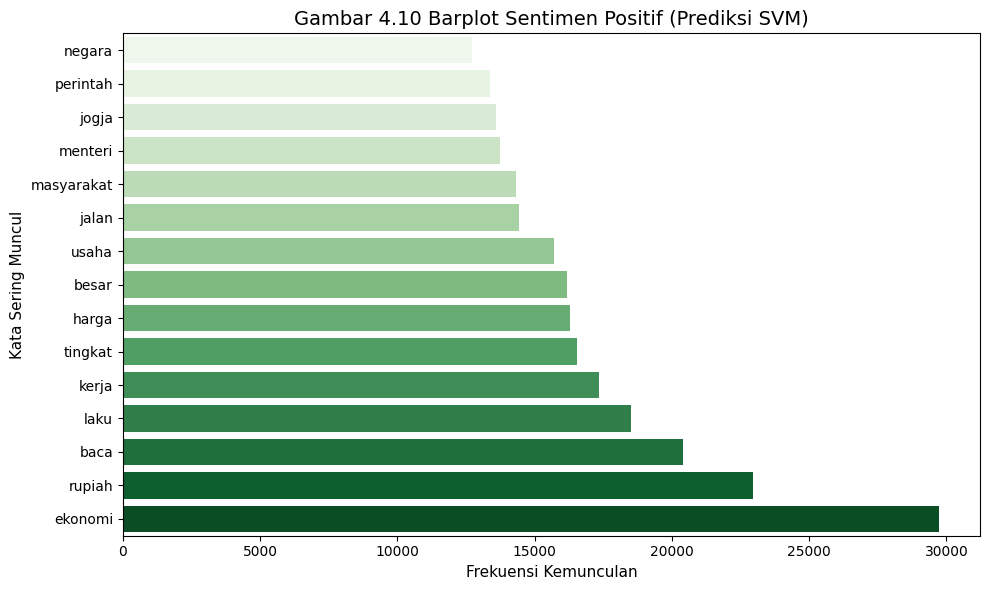

In [15]:
# --- VISUALISASI WORDCLOUD DAN BARPLOT SENTIMEN POSITIF ---
print("--- Visualisasi Sentimen Positif (Berdasarkan Prediksi SVM) ---")

# Filter data berdasarkan sentimen Positif dari HASIL PREDIKSI SVM
positive_predicted_sentiment_data = all_predicted_data[all_predicted_data['Predicted_Sentiment_SVM'] == 'Positive']

# WordCloud Positif
if not positive_predicted_sentiment_data.empty:
    predicted_positive_text = ' '.join(positive_predicted_sentiment_data['Stemmed_Text'].astype(str).tolist())
    predicted_positive_tokens = [word for word in predicted_positive_text.split() if word.lower() not in stopwords_indo]
    predicted_positive_word_counts = Counter(predicted_positive_tokens)

    wc_predicted_positive = WordCloud(
        background_color='white',
        width=800,
        height=800,
        max_words=500,
        stopwords=stopwords_indo,
        colormap='Greens' # Colormap yang cocok untuk positif
    ).generate_from_frequencies(predicted_positive_word_counts)

    plt.figure(figsize=(10, 6)) # Ukuran figura disesuaikan untuk skripsi
    plt.imshow(wc_predicted_positive, interpolation='bilinear')
    plt.axis("off")
    plt.title("Gambar 4.9 WordCloud Sentimen Positif (Prediksi SVM)", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada data dengan sentimen Positif (prediksi SVM) untuk WordCloud.")

# Barplot Positif
if not positive_predicted_sentiment_data.empty:
    top_positive_words = predicted_positive_word_counts.most_common(15)
    words_pos, counts_pos = zip(*top_positive_words)

    plt.figure(figsize=(10, 6))
    # --- PERBAIKAN DI SINI ---
    # sns.barplot(x=list(counts_pos), y=list(words_pos), palette='lightgreen', orient='h') # INI YG SALAH
    sns.barplot(x=list(counts_pos), y=list(words_pos), palette='Greens_r', orient='h') # Pilihan 1: Menggunakan palette 'Greens_r' (reversed Greens)
    # Atau jika ingin warna solid spesifik:
    # sns.barplot(x=list(counts_pos), y=list(words_pos), color='lightgreen', orient='h') # Pilihan 2: Menggunakan argumen 'color' untuk warna solid tunggal

    plt.xlabel("Frekuensi Kemunculan", fontsize=11)
    plt.ylabel("Kata Sering Muncul", fontsize=11)
    plt.title("Gambar 4.10 Barplot Sentimen Positif (Prediksi SVM)", fontsize=14)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada data dengan sentimen Positif (prediksi SVM) untuk Barplot.")


--- Visualisasi Sentimen Positif (Berdasarkan Prediksi SVM) ---


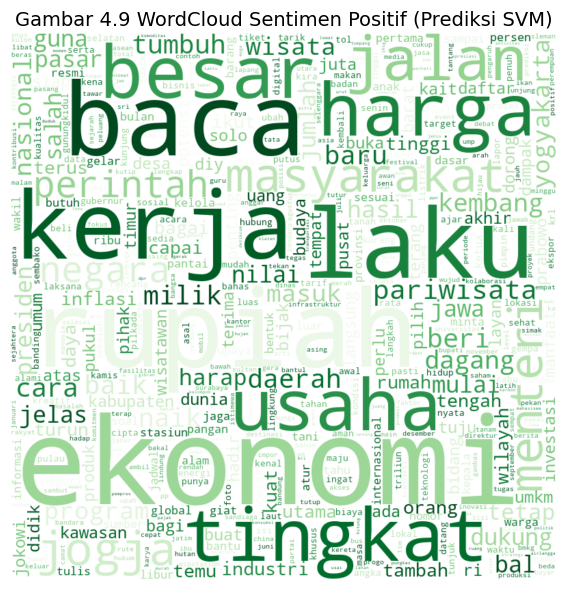

In [19]:
# --- VISUALISASI WORDCLOUD DAN BARPLOT SENTIMEN POSITIF ---
print("--- Visualisasi Sentimen Positif (Berdasarkan Prediksi SVM) ---")

# Filter data berdasarkan sentimen Positif dari HASIL PREDIKSI SVM
positive_predicted_sentiment_data = all_predicted_data[all_predicted_data['Predicted_Sentiment_SVM'] == 'Positive']

# WordCloud Positif
if not positive_predicted_sentiment_data.empty:
    predicted_positive_text = ' '.join(positive_predicted_sentiment_data['Stemmed_Text'].astype(str).tolist())
    predicted_positive_tokens = [word for word in predicted_positive_text.split() if word.lower() not in stopwords_indo]
    predicted_positive_word_counts = Counter(predicted_positive_tokens)

    wc_predicted_positive = WordCloud(
        background_color='white',
        width=800,
        height=800,
        max_words=500,
        stopwords=stopwords_indo,
        colormap='Greens' # Colormap yang cocok untuk positif
    ).generate_from_frequencies(predicted_positive_word_counts)

    plt.figure(figsize=(10, 6)) # Ukuran figura disesuaikan untuk skripsi
    plt.imshow(wc_predicted_positive, interpolation='bilinear')
    plt.axis("off")
    plt.title("Gambar 4.9 WordCloud Sentimen Positif (Prediksi SVM)", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada data dengan sentimen Positif (prediksi SVM) untuk WordCloud.")

--- Visualisasi Sentimen Positif (Berdasarkan Prediksi SVM) ---


C:\Users\asus\AppData\Local\Temp\ipykernel_15932\2496091732.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts_pos, y=words_pos, palette='Greens', orient='h')


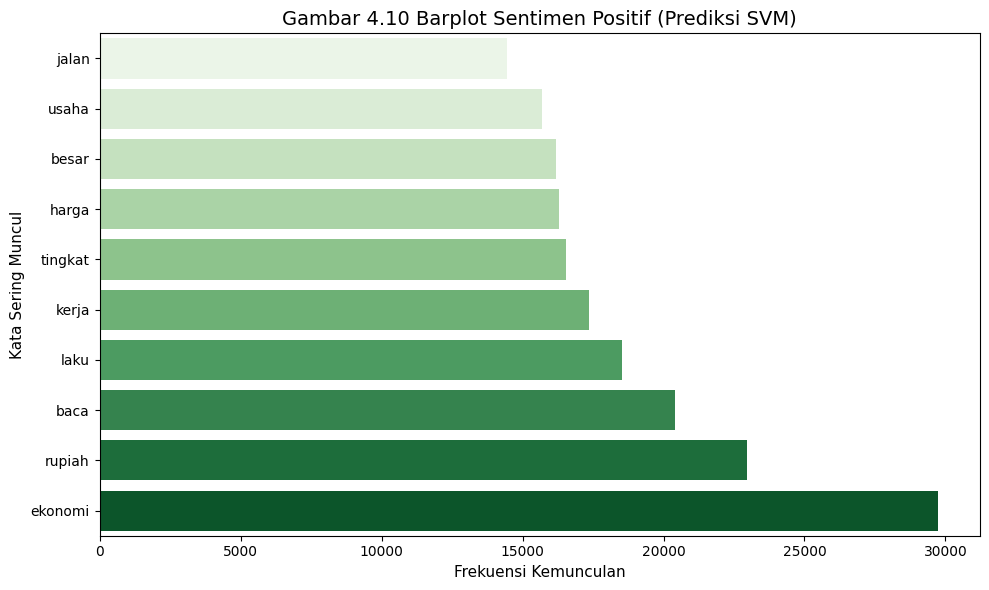

In [27]:
# --- VISUALISASI BARPLOT SENTIMEN POSITIF ---
print("--- Visualisasi Sentimen Positif (Berdasarkan Prediksi SVM) ---")

if not positive_predicted_sentiment_data.empty:
    predicted_positive_text = ' '.join(positive_predicted_sentiment_data['Stemmed_Text'].astype(str).tolist())
    predicted_positive_tokens = [word for word in predicted_positive_text.split() if word.lower() not in stopwords_indo]
    predicted_positive_word_counts = Counter(predicted_positive_tokens)

    top_positive_words = predicted_positive_word_counts.most_common(10)

    # --- PERBAIKAN UNTUK URUTAN DI SINI ---
    # Membalik urutan agar yang paling banyak muncul di atas ketika plot horizontal
    words_pos = [word for word, count in reversed(top_positive_words)] # Membalik daftar kata
    counts_pos = [count for word, count in reversed(top_positive_words)] # Membalik daftar frekuensi

    plt.figure(figsize=(10, 6))
    sns.barplot(x=counts_pos, y=words_pos, palette='Greens', orient='h')
    plt.xlabel("Frekuensi Kemunculan", fontsize=11)
    plt.ylabel("Kata Sering Muncul", fontsize=11)
    plt.title("Gambar 4.10 Barplot Sentimen Positif (Prediksi SVM)", fontsize=14)
    # plt.gca().invert_yaxis() # <--- HAPUS BARIS INI
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada data dengan sentimen Positif (prediksi SVM) untuk Barplot.")


--- Visualisasi Sentimen Negatif (Berdasarkan Prediksi SVM) ---


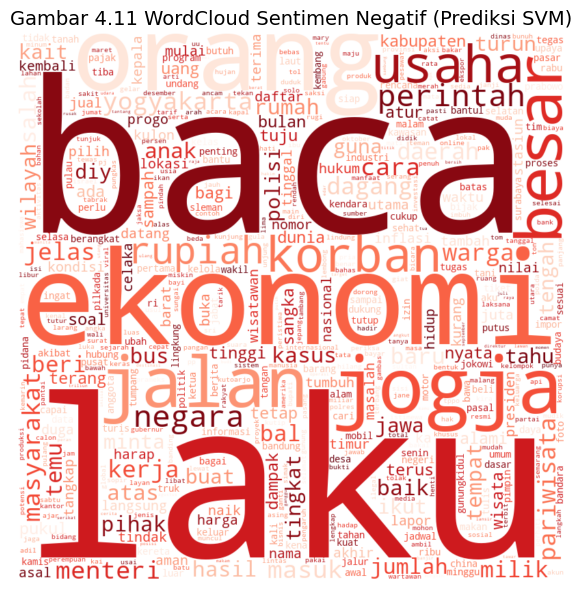

In [28]:
# --- VISUALISASI WORDCLOUD DAN BARPLOT SENTIMEN NEGATIF ---

print("\n--- Visualisasi Sentimen Negatif (Berdasarkan Prediksi SVM) ---")

# WordCloud Negatif (ini sudah benar)
if not negative_predicted_sentiment_data.empty:
    predicted_negative_text = ' '.join(negative_predicted_sentiment_data['Stemmed_Text'].astype(str).tolist())
    predicted_negative_tokens = [word for word in predicted_negative_text.split() if word.lower() not in stopwords_indo]
    predicted_negative_word_counts = Counter(predicted_negative_tokens)

    wc_predicted_negative = WordCloud(
        background_color='white',
        width=800,
        height=800,
        max_words=500,
        stopwords=stopwords_indo,
        colormap='Reds' # <-- Menggunakan colormap yang dikenal
    ).generate_from_frequencies(predicted_negative_word_counts)

    plt.figure(figsize=(10, 6))
    plt.imshow(wc_predicted_negative, interpolation='bilinear')
    plt.axis("off")
    plt.title("Gambar 4.11 WordCloud Sentimen Negatif (Prediksi SVM)", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada data dengan sentimen Negatif (prediksi SVM) untuk WordCloud.")


--- Visualisasi Sentimen Negatif (Berdasarkan Prediksi SVM) ---


C:\Users\asus\AppData\Local\Temp\ipykernel_15932\4129254004.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts_neg, y=words_neg, palette='Reds', orient='h') # Menggunakan palette 'Reds'


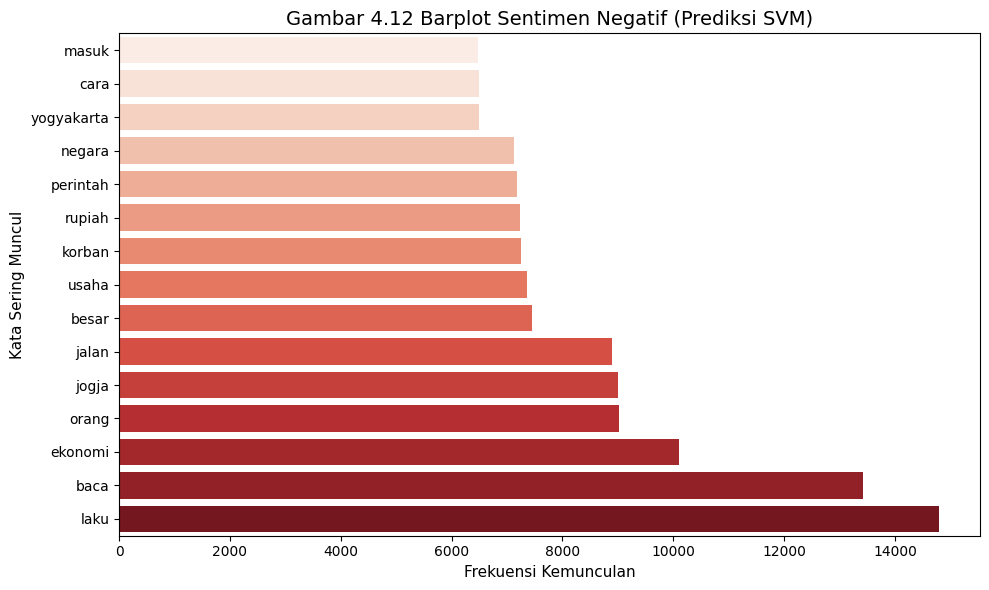

In [32]:
# --- VISUALISASI BARPLOT SENTIMEN NEGATIF ---
print("\n--- Visualisasi Sentimen Negatif (Berdasarkan Prediksi SVM) ---")

if not negative_predicted_sentiment_data.empty:
    predicted_negative_text = ' '.join(negative_predicted_sentiment_data['Stemmed_Text'].astype(str).tolist())
    predicted_negative_tokens = [word for word in predicted_negative_text.split() if word.lower() not in stopwords_indo]
    predicted_negative_word_counts = Counter(predicted_negative_tokens)

    top_negative_words = predicted_negative_word_counts.most_common(15)

    # Membalik urutan agar yang paling banyak muncul di atas ketika plot horizontal
    words_neg = [word for word, count in reversed(top_negative_words)]
    counts_neg = [count for word, count in reversed(top_negative_words)]

    plt.figure(figsize=(10, 6))
    # --- PERBAIKAN DI SINI: HAPUS '_r' dari palette ---
    sns.barplot(x=counts_neg, y=words_neg, palette='Reds', orient='h') # Menggunakan palette 'Reds'
    # Alternatif: jika ingin warna solid tanpa gradasi, gunakan 'color' saja:
    # sns.barplot(x=counts_neg, y=words_neg, color='firebrick', orient='h') # Contoh warna solid merah gelap

    plt.xlabel("Frekuensi Kemunculan", fontsize=11)
    plt.ylabel("Kata Sering Muncul", fontsize=11)
    plt.title("Gambar 4.12 Barplot Sentimen Negatif (Prediksi SVM)", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada data dengan sentimen Negatif (prediksi SVM) untuk Barplot.")


--- Visualisasi Sentimen Positif (Berdasarkan Prediksi SVM) ---


C:\Users\asus\AppData\Local\Temp\ipykernel_15932\2999604620.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts_pos, y=words_pos, palette='Greens', orient='h')


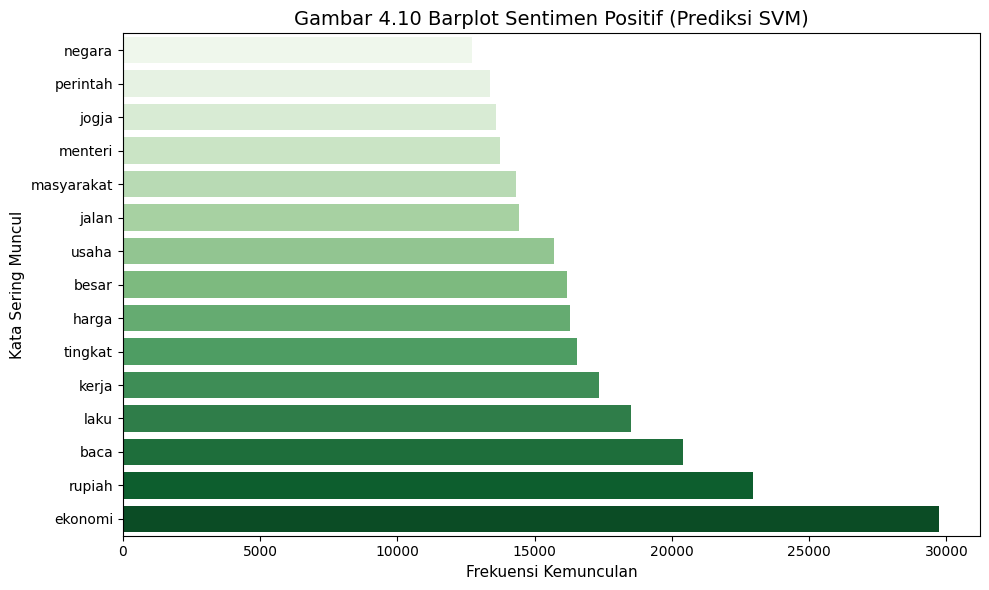

In [31]:
# --- VISUALISASI BARPLOT SENTIMEN POSITIF ---
print("--- Visualisasi Sentimen Positif (Berdasarkan Prediksi SVM) ---")

if not positive_predicted_sentiment_data.empty:
    predicted_positive_text = ' '.join(positive_predicted_sentiment_data['Stemmed_Text'].astype(str).tolist())
    predicted_positive_tokens = [word for word in predicted_positive_text.split() if word.lower() not in stopwords_indo]
    predicted_positive_word_counts = Counter(predicted_positive_tokens)

    top_positive_words = predicted_positive_word_counts.most_common(15)

    # --- PERBAIKAN UNTUK URUTAN DI SINI ---
    # Membalik urutan agar yang paling banyak muncul di atas ketika plot horizontal
    words_pos = [word for word, count in reversed(top_positive_words)] # Membalik daftar kata
    counts_pos = [count for word, count in reversed(top_positive_words)] # Membalik daftar frekuensi

    plt.figure(figsize=(10, 6))
    sns.barplot(x=counts_pos, y=words_pos, palette='Greens', orient='h')
    plt.xlabel("Frekuensi Kemunculan", fontsize=11)
    plt.ylabel("Kata Sering Muncul", fontsize=11)
    plt.title("Gambar 4.10 Barplot Sentimen Positif (Prediksi SVM)", fontsize=14)
    # plt.gca().invert_yaxis() # <--- HAPUS BARIS INI
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada data dengan sentimen Positif (prediksi SVM) untuk Barplot.")

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
from collections import Counter
import seaborn as sns # Untuk barplot

# --- ASUMSI: all_predicted_data SUDAH ADA DARI CODE SEBELUMNYA ---
# all_predicted_data ini adalah DataFrame yang berisi kolom 'Stemmed_Text'
# dan 'Predicted_Sentiment_SVM' (hasil prediksi dari model SVM terbaik)

# Contoh data dummy jika Anda belum punya all_predicted_data dari running code sebelumnya
# Jika Anda sudah menjalankan code yang menghasilkan all_predicted_data, baris ini bisa dihapus
# data_contoh = {
#     'Stemmed_Text': [
#         "ekonomi yogyakarta semakin hari semakin merasakan air sumur semakin sulit membuat sumur semakin dalam kemarau sumur kekeringan terjadi penyebabnya sektor pariwisata primadona yogyakarta seringkali disertai pengendalian pengawasan optimal pembangunan hotel menjamur setiap sudut kota",
#         "yogyakarta menteri pariwisata ekonomi kreatif sandiaga salahuddin uno kembali buka desa wisata kaki langit bantul yogyakarta",
#         "inflasi pangan tinggi masyarakat kesulitan",
#         "pemerintah tingkatkan ekspor produk lokal dorong pertumbuhan ekonomi",
#         "harga kebutuhan pokok naik daya beli masyarakat menurun",
#         "investasi infrastruktur baru dorong lapangan kerja"
#     ],
#     'Predicted_Sentiment_SVM': ['Negative', 'Positive', 'Negative', 'Positive', 'Negative', 'Positive']
# }
# all_predicted_data = pd.DataFrame(data_contoh)
# --- AKHIR DUMMY DATA ---


# Daftar stopwords tambahan Anda (gunakan yang sama dengan sebelumnya)
stopwords_indo = set(STOPWORDS)
stopwords_indo.update([
    'advertisement', 'content', 'continue', 'wib', 'scroll', 'nan', 'indonesia',
    'tahun', 'jadi', 'ya', 'jawa barat', 'lanjut', 'lihat', 'untuk', 'dengan',
    'jakarta', 'kata', 'ujar', 'sebut', 'ungkap', 'jela', 'dapat', 'satu',
    'dua', 'tiga', 'jawa timur', 'ucap', 'judul', 'author', 'video', 'detik', 'turut',
    # Tambahkan stopword dari stemming/normalization jika masih ada
    'semakin', 'membuat', 'rasa', 'sulit', 'terjadi', 'penyebabnya', 'seringkali', 'sertai',
    'kendali', 'awas', 'bangun', 'jamur', 'tiap', 'setiap', 'sudut', 'kota', 'hari', 'air',
    'sumur', 'dalam', 'kemarau', 'kering', 'sebab', 'sektor', 'primadona', 'disertai',
    'pengendalian', 'pengawasan', 'optimal', 'pembangunan', 'hotel', 'menjamur'
])


# --- FILTERING DATA BERDASARKAN SENTIMEN PREDIKSI SVM ---
positive_predicted_data = all_predicted_data[all_predicted_data['Predicted_Sentiment_SVM'] == 'Positive']
negative_predicted_data = all_predicted_data[all_predicted_data['Predicted_Sentiment_SVM'] == 'Negative']


# --- VISUALISASI WORDCLOUD DAN BARPLOT SENTIMEN POSITIF ---

print("--- Visualisasi Sentimen Positif (Berdasarkan Prediksi SVM) ---")

# WordCloud Positif
if not positive_predicted_data.empty:
    predicted_positive_text = ' '.join(positive_predicted_data['Stemmed_Text'].astype(str).tolist())
    predicted_positive_tokens = [word for word in predicted_positive_text.split() if word.lower() not in stopwords_indo]
    predicted_positive_word_counts = Counter(predicted_positive_tokens)

    wc_predicted_positive = WordCloud(
        background_color='white',
        width=800,
        height=800,
        max_words=500,
        stopwords=stopwords_indo,
        colormap='Greens' # Colormap yang cocok untuk positif
    ).generate_from_frequencies(predicted_positive_word_counts)

    plt.figure(figsize=(10, 6)) # Ukuran figura disesuaikan untuk skripsi
    plt.imshow(wc_predicted_positive, interpolation='bilinear')
    plt.axis("off")
    plt.title("Gambar 4.9 WordCloud Sentimen Positif (Prediksi SVM)", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada data dengan sentimen Positif (prediksi SVM) untuk WordCloud.")

# Barplot Positif
if not positive_predicted_data.empty:
    top_positive_words = predicted_positive_word_counts.most_common(15) # Ambil 15 kata teratas
    words_pos, counts_pos = zip(*top_positive_words)

    plt.figure(figsize=(10, 6)) # Ukuran figura disesuaikan untuk skripsi
    sns.barplot(x=list(counts_pos), y=list(words_pos), palette='lightgreen', orient='h')
    plt.xlabel("Frekuensi Kemunculan", fontsize=11)
    plt.ylabel("Kata Sering Muncul", fontsize=11)
    plt.title("Gambar 4.10 Barplot Sentimen Positif (Prediksi SVM)", fontsize=14)
    plt.gca().invert_yaxis() # Kata frekuensi tertinggi di atas
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada data dengan sentimen Positif (prediksi SVM) untuk Barplot.")


# --- VISUALISASI WORDCLOUD DAN BARPLOT SENTIMEN NEGATIF ---

print("\n--- Visualisasi Sentimen Negatif (Berdasarkan Prediksi SVM) ---")

# WordCloud Negatif
if not negative_predicted_data.empty:
    predicted_negative_text = ' '.join(negative_predicted_data['Stemmed_Text'].astype(str).tolist())
    predicted_negative_tokens = [word for word in predicted_negative_text.split() if word.lower() not in stopwords_indo]
    predicted_negative_word_counts = Counter(predicted_negative_tokens)

    wc_predicted_negative = WordCloud(
        background_color='white',
        width=800,
        height=800,
        max_words=500,
        stopwords=stopwords_indo,
        colormap='Reds' # Colormap yang cocok untuk negatif
    ).generate_from_frequencies(predicted_negative_word_counts)

    plt.figure(figsize=(10, 6)) # Ukuran figura disesuaikan untuk skripsi
    plt.imshow(wc_predicted_negative, interpolation='bilinear')
    plt.axis("off")
    plt.title("Gambar 4.11 WordCloud Sentimen Negatif (Prediksi SVM)", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada data dengan sentimen Negatif (prediksi SVM) untuk WordCloud.")

# Barplot Negatif
if not negative_predicted_data.empty:
    top_negative_words = predicted_negative_word_counts.most_common(15) # Ambil 15 kata teratas
    words_neg, counts_neg = zip(*top_negative_words)

    plt.figure(figsize=(10, 6)) # Ukuran figura disesuaikan untuk skripsi
    sns.barplot(x=list(counts_neg), y=list(words_neg), palette='lightcoral', orient='h')
    plt.xlabel("Frekuensi Kemunculan", fontsize=11)
    plt.ylabel("Kata Sering Muncul", fontsize=11)
    plt.title("Gambar 4.12 Barplot Sentimen Negatif (Prediksi SVM)", fontsize=14)
    plt.gca().invert_yaxis() # Kata frekuensi tertinggi di atas
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada data dengan sentimen Negatif (prediksi SVM) untuk Barplot.")